<h2>Matplotlib: основы визуализации данных в Python</h2>

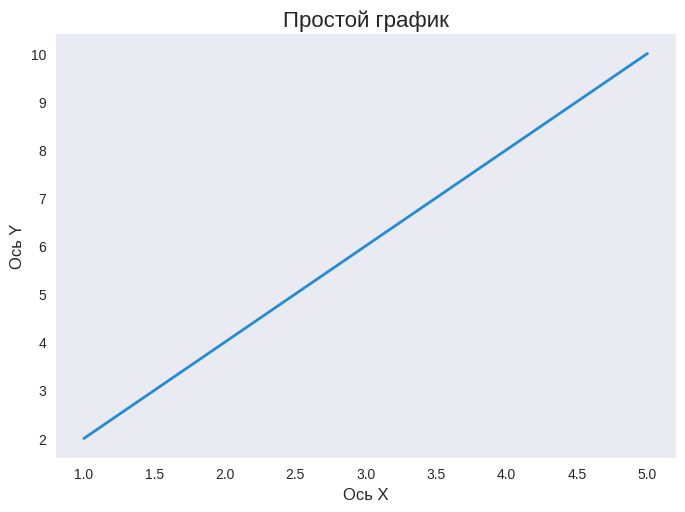

In [64]:
import matplotlib.pyplot as plt

# Создаем данные
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

# Создаем график
plt.plot(x, y)

# Добавляем заголовки
plt.title("Простой график")
plt.xlabel("Ось X")
plt.ylabel("Ось Y")

# Показываем график
plt.show()

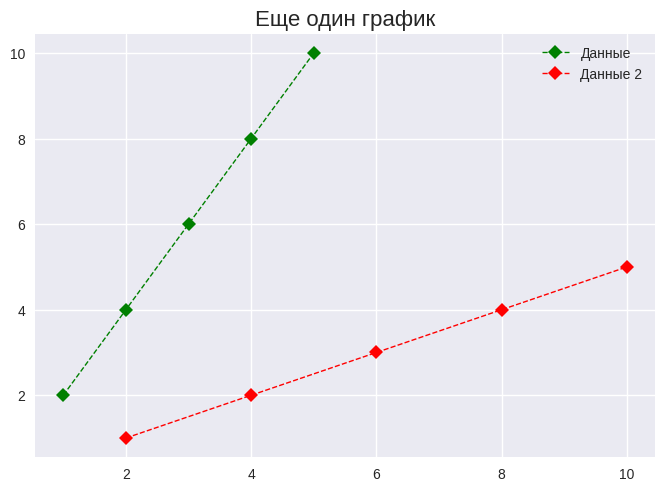

In [65]:
# linestyles: '-', '--', '-.', ':'
# markers: 'o', 's', 'D', '^', 'v', '*', 'x', 'X', 'p', 'h'

plt.plot(x, y, color='green', linestyle='--', linewidth=1, marker='D', label='Данные')
plt.plot(y, x, color='red', linestyle='--', linewidth=1, marker='D', label='Данные 2')
plt.legend()
plt.title("Еще один график")
plt.grid()
plt.show()

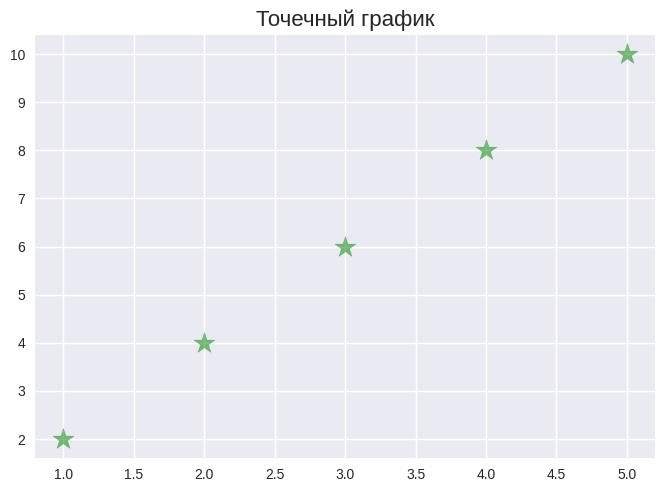

In [66]:
plt.scatter(x, y, c='green', marker='*', s=250, alpha=0.5)
plt.grid()
plt.title("Точечный график")
plt.show()

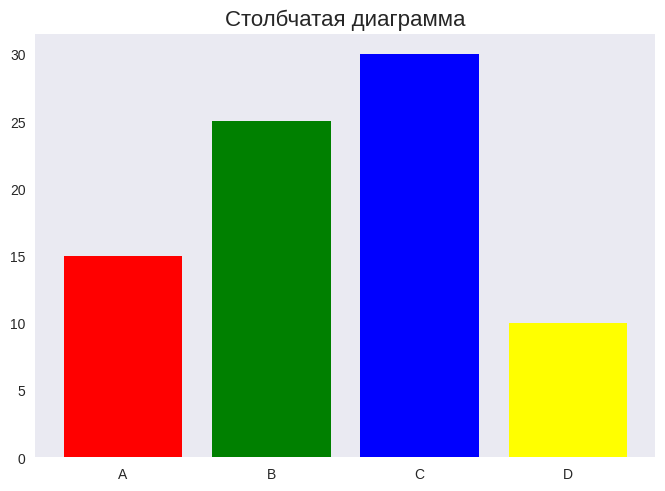

In [67]:
categories = ['A', 'B', 'C', 'D']
values = [15, 25, 30, 10]
plt.bar(categories, values, color=['red', 'green', 'blue', 'yellow'])
plt.title("Столбчатая диаграмма")
plt.show()

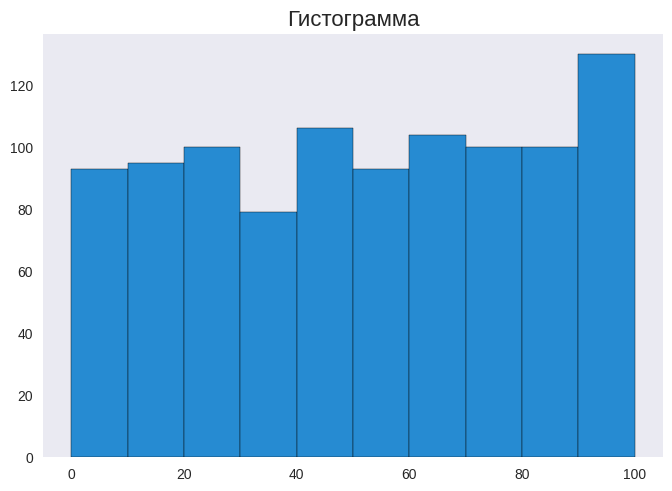

In [68]:
import random
data = [random.randint(0, 100) for x in range(1000)]

plt.hist(data, bins=10, edgecolor='black')
plt.title("Гистограмма")
plt.show()

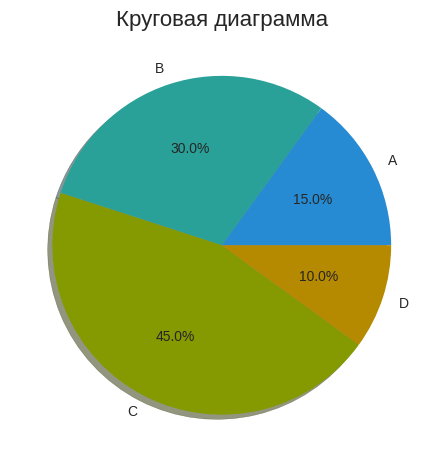

In [69]:
sizes = [15, 30, 45, 10]
labels = ['A', 'B', 'C', 'D']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', shadow=True)
# autopct: '%1.1f%%', '%d%%', '%.2ff%%'

plt.title("Круговая диаграмма")
plt.show()

<h2>Работа с несколькими графиками</h2>

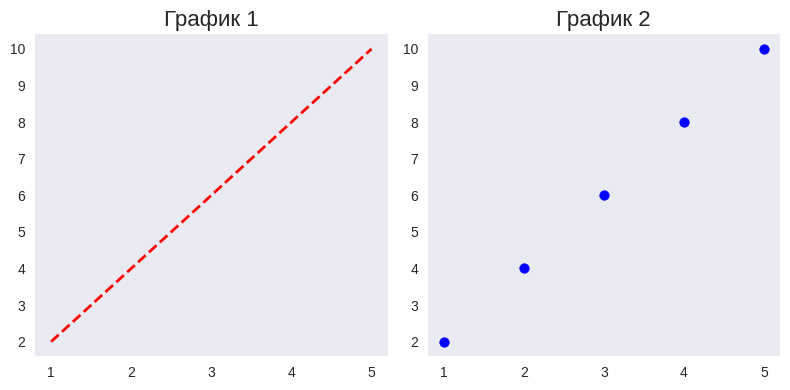

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4)) # аргументы - число строк, число колонок

ax1.plot(x, y, 'r--')
ax1.set_title('График 1')

ax2.scatter(x, y, c='b')
ax2.set_title('График 2')

plt.tight_layout()
plt.show()

In [71]:
print(plt.style.available)  # Показать доступные стили

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


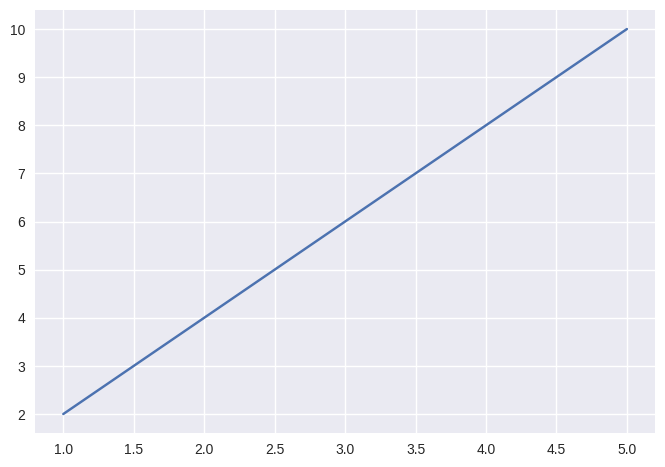

In [72]:
plt.style.use('seaborn-v0_8')  # Применить стиль

# Теперь все графики будут в стиле seaborn-v0_8
plt.plot(x, y)
plt.show()

Сохранение в файл:

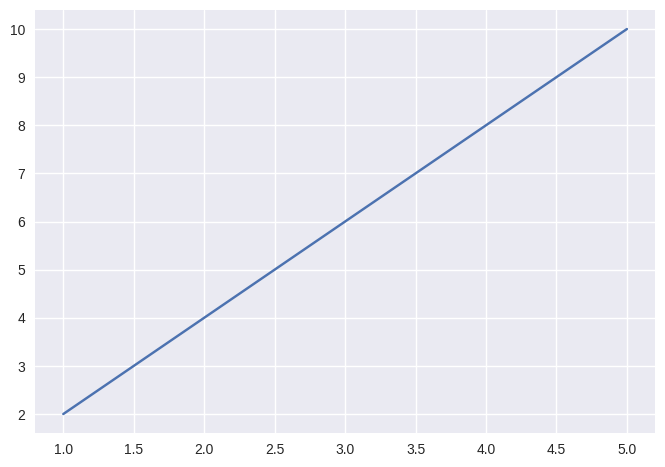

In [73]:
plt.plot(x, y)
plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')

Построим графики по данным, полученным при парсинге истории канала ОКСФ.

In [74]:
!wget https://phonetics-spbu.github.io/courses/python_1_mag/files/oksf_stat.csv

--2026-05-12 11:31:24--  https://phonetics-spbu.github.io/courses/python_1_mag/files/oksf_stat.csv
Resolving phonetics-spbu.github.io (phonetics-spbu.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to phonetics-spbu.github.io (phonetics-spbu.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3253 (3.2K) [text/csv]
Saving to: ‘oksf_stat.csv.1’

oksf_stat.csv.1     100%[===================>]   3.18K  --.-KB/s    in 0s      

2026-05-12 11:31:25 (48.1 MB/s) - ‘oksf_stat.csv.1’ saved [3253/3253]



Нарисуем график количества лайков под постами:

In [122]:
import csv

with open("oksf_stat.csv", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    data = list(reader)
    header = reader.fieldnames

In [76]:
header

['дата', 'время', 'длина сообщения', 'есть ли картинка', 'количество реакций']

In [77]:
data[:2]

[{'дата': '2024-12-23',
  'время': '01:20:25',
  'длина сообщения': '0',
  'есть ли картинка': 'False',
  'количество реакций': '0'},
 {'дата': '2024-12-24',
  'время': '13:37:51',
  'длина сообщения': '1423',
  'есть ли картинка': 'True',
  'количество реакций': '5'}]

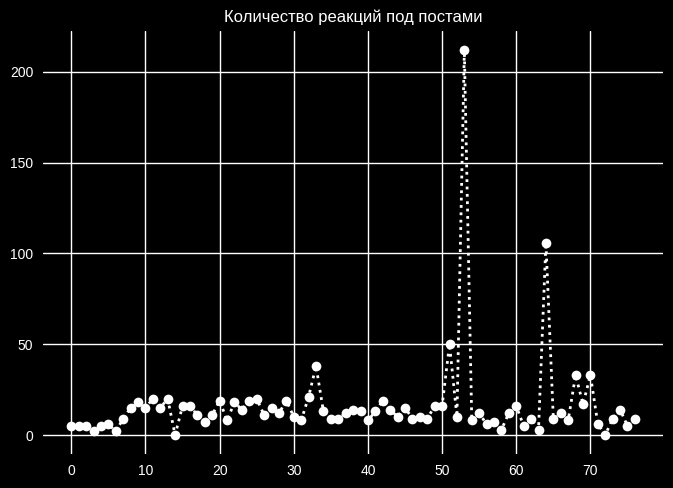

In [78]:
reactions_number = [int(row['количество реакций']) for row in data if int(row['длина сообщения']) > 0]

plt.style.use('dark_background')

plt.plot(reactions_number, color='white', linestyle=':', linewidth=2, marker='o')
plt.title("Количество реакций под постами")
plt.grid(True)
plt.show()

Построим столбчатую диаграмму: посты с картинками, просто картинки, технические сообщения (нет ни картинки, ни текста)

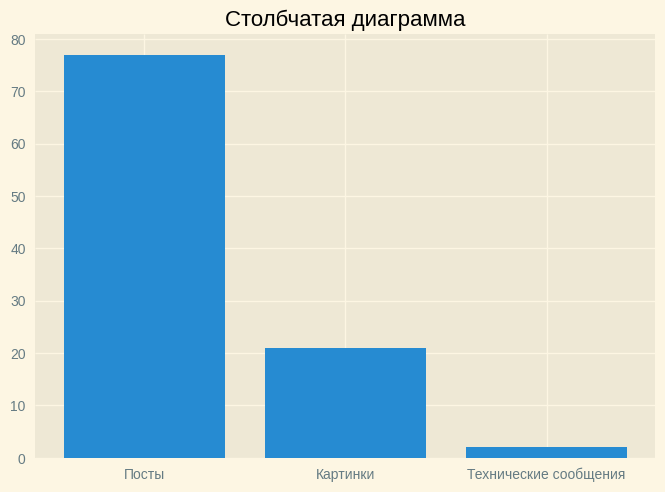

In [79]:
categories = ['Посты', 'Картинки', 'Технические сообщения']

posts_num = len([row for row in data if int(row['длина сообщения']) > 0])
pics_num = len([row for row in data if int(row['длина сообщения']) == 0 and row['есть ли картинка'] == "True"])
tech_num = len([row for row in data if (int(row['длина сообщения']) == 0 and row['есть ли картинка'] == "False")])

values = [posts_num, pics_num, tech_num]

plt.style.use('Solarize_Light2')
plt.bar(categories, values)
plt.title("Столбчатая диаграмма", color="black")
plt.show()

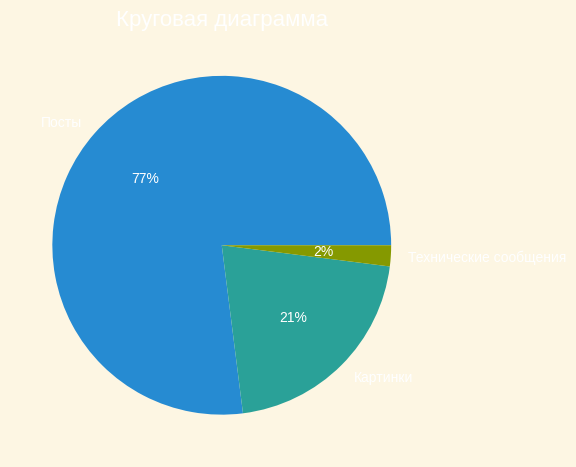

In [80]:
sizes = [posts_num, pics_num, tech_num]
labels = ['Посты', 'Картинки', 'Технические сообщения']
plt.pie(sizes, labels=labels, autopct='%d%%')

plt.style.use("seaborn-v0_8-dark")
plt.title("Круговая диаграмма")
plt.show()

Построим точечную диаграмму длина сообщения - количество реакций:

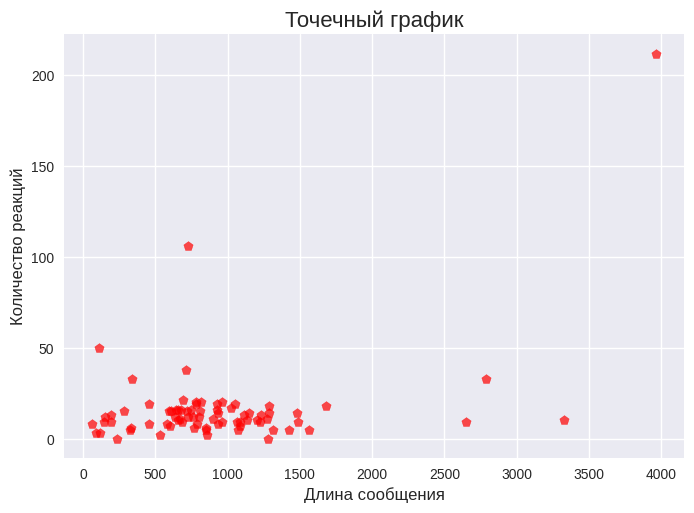

In [81]:
msg_length = [int(row['длина сообщения']) for row in data if int(row['длина сообщения']) > 0]

plt.scatter(msg_length, reactions_number, c='red', marker='p', s=50, alpha=0.7)
plt.xlabel("Длина сообщения")
plt.ylabel("Количество реакций")
plt.grid()
plt.title("Точечный график")
plt.show()

In [82]:
!wget https://phonetics-spbu.github.io/courses/python_1_mag/files/Бармаглот.txt

--2026-05-12 11:31:25--  https://phonetics-spbu.github.io/courses/python_1_mag/files/%D0%91%D0%B0%D1%80%D0%BC%D0%B0%D0%B3%D0%BB%D0%BE%D1%82.txt
Resolving phonetics-spbu.github.io (phonetics-spbu.github.io)... 185.199.108.153, 185.199.109.153, 185.199.110.153, ...
Connecting to phonetics-spbu.github.io (phonetics-spbu.github.io)|185.199.108.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1149 (1.1K) [text/plain]
Saving to: ‘Бармаглот.txt.1’

Бармаглот.txt.1     100%[===================>]   1.12K  --.-KB/s    in 0s      

2026-05-12 11:31:25 (61.2 MB/s) - ‘Бармаглот.txt.1’ saved [1149/1149]



Задача. Прочитайте текстовый файл Бармаглот.txt. Посчитайте длину каждого слова и постройте столбчатую диаграмму.

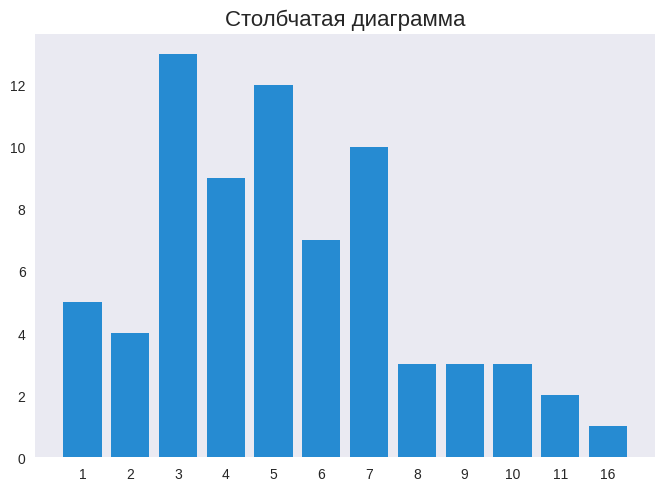

In [123]:
import string

with open("Бармаглот.txt", "r") as file:
  text = file.read()

text_without_punct = text.translate(str.maketrans("", "", string.punctuation)).lower()

words = text_without_punct.split()
words = set([word for word in words if word != '–'])

word_lens = [len(word) for word in words]

word_lens_dict = {}

for word_len in word_lens:
  if word_len in word_lens_dict.keys():
    word_lens_dict[word_len] += 1
  else:
    word_lens_dict[word_len] = 1

categories = sorted(word_lens_dict.keys())
values = [word_lens_dict[key] for key in categories]
categories = [str(key) for key in categories]
plt.bar(categories, values)
plt.title("Столбчатая диаграмма")
plt.show()

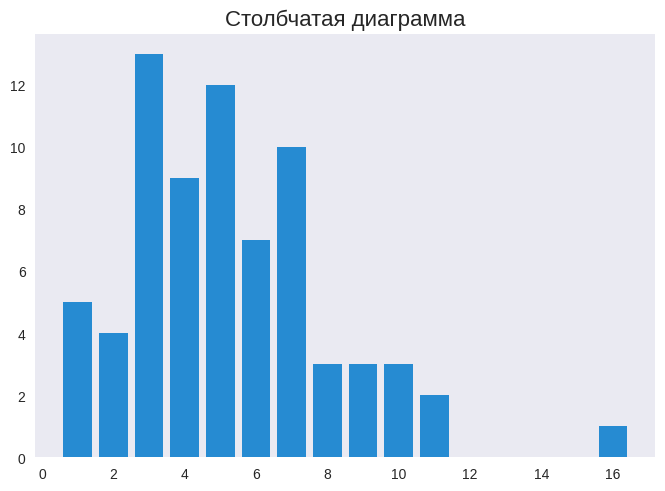

In [102]:
categories = word_lens_dict.keys()
values = [word_lens_dict[key] for key in categories]
plt.bar(categories, values)
plt.title("Столбчатая диаграмма")
plt.show()

Задача. Подсчитайте частоту каждого символа (кроме пробелов) и постройте круговую диаграмму топ-3 символов.

Text(0.5, 1.0, 'Круговая диаграмма')

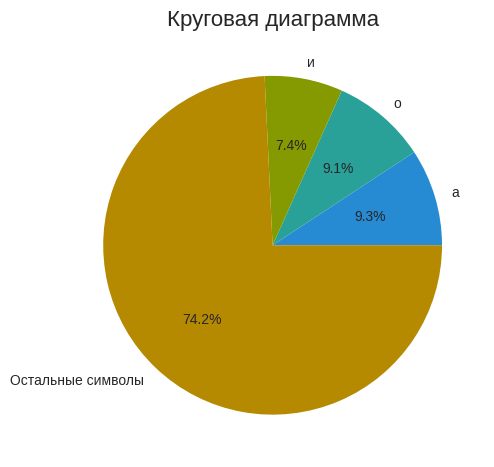

In [113]:
symb_dict = {}

for symb in text_without_punct:
  if not symb.isalpha():
    continue
  if symb in symb_dict.keys():
    symb_dict[symb] += 1
  else:
    symb_dict[symb] = 1

sorted_symb_dict = dict(sorted(symb_dict.items(), key=lambda item: item[1], reverse=True))
top_3 = list(sorted_symb_dict.keys())[:3]

total_symbols = len([symb for symb in text_without_punct if symb.isalpha()])

sizes = []
labels = top_3

for symb in top_3:
  sizes.append(sorted_symb_dict[symb])

sizes.append(total_symbols - sum(sizes))

labels.append("Остальные символы")

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
# autopct: '%1.1f%%', '%d%%', '%.2ff%%'

plt.title("Круговая диаграмма")

Задача. Посчитайте количество гласных и согласных букв (без учета регистра) и постройте столбчатую диаграмму.

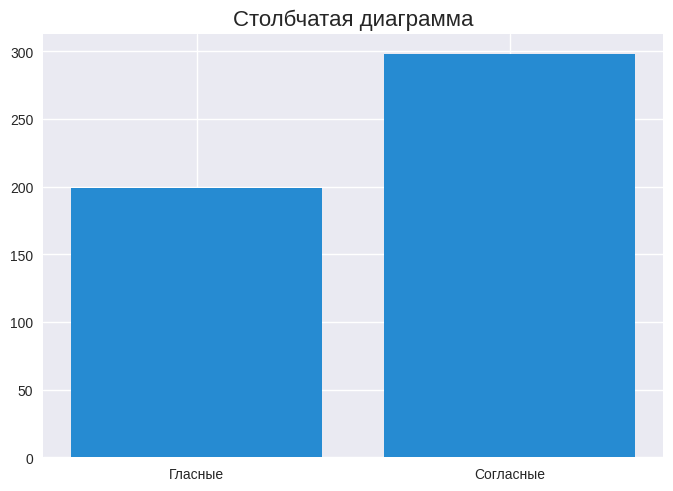

In [116]:
vowels_count = 0
for key in symb_dict.keys():
  if key in ("уеыаоэяиюё"):
    vowels_count += symb_dict[key]

cons_count = total_symbols - vowels_count

categories = ["Гласные", "Согласные"]
values = [vowels_count, cons_count]
plt.bar(categories, values)
plt.title("Столбчатая диаграмма")
plt.grid()
plt.show()

Задача. Постройте график зависимости длины предложения от его номера. Предложения в тексте могут заканчиваться на точку или восклицательный знак.

Text(0.5, 0, 'Номер предложения')

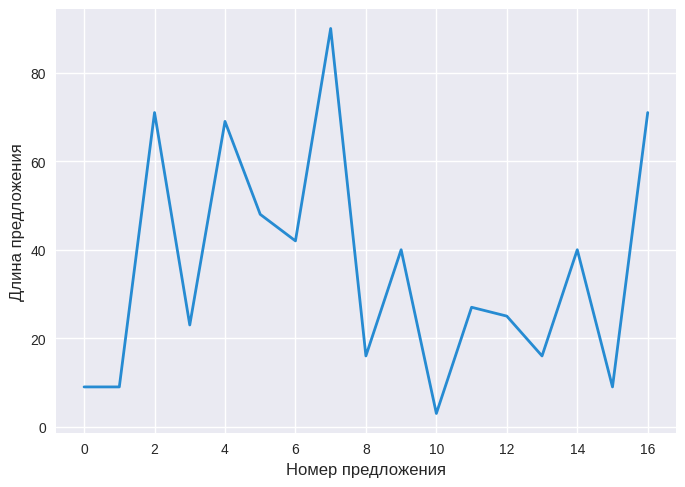

In [131]:
text_replaced = text.replace("!", ".")

sentences = text_replaced.split(".")

sentences = [sentence.strip() for sentence in sentences if len(sentence) > 0]

sentences_lens = [len(sentence) for sentence in sentences]

plt.plot(sentences_lens)
plt.grid()
plt.ylabel("Длина предложения")
plt.xlabel("Номер предложения")

Задача. Постройте точечный график зависимости длины предложения от средней длины слова в нем.

In [136]:
sentences_word_lens = [[len(word) for word in sentence.split()] for sentence in sentences]

In [139]:
sentences_avg_word_lens = [sum(len_sentence) / len(len_sentence) for len_sentence in sentences_word_lens]

Text(0.5, 0, 'Средняя длина слова в предложении')

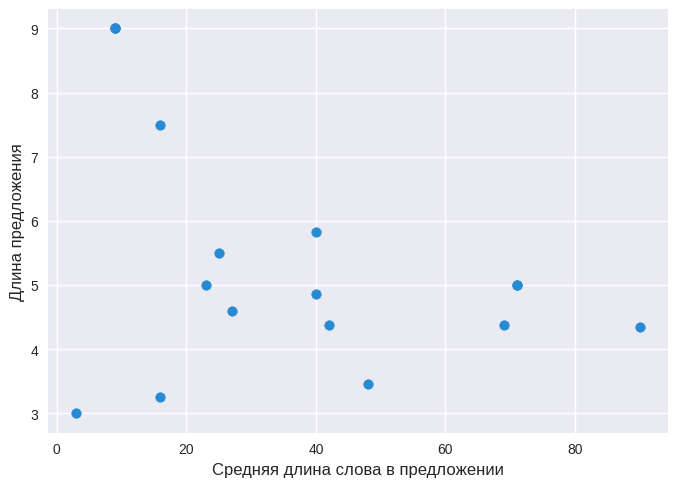

In [142]:
plt.scatter(sentences_lens, sentences_avg_word_lens)
plt.grid()
plt.ylabel("Длина предложения")
plt.xlabel("Средняя длина слова в предложении")